# 03 - KMeans Clustering

This notebook loads the full scaled 10,000-row preprocessing output, reduces it with PCA, uses the elbow method to choose the number of clusters, fits KMeans in a 10-component PCA space, visualizes clusters with 2-component PCA and t-SNE, and profiles the resulting groups.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

BASE_DIR = Path('..').resolve()
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOTS_DIR = BASE_DIR / 'plots' / 'clustering'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

X_scaled = pd.read_csv(PROCESSED_DIR / 'X_scaled.csv')
source_df = pd.read_csv(PROCESSED_DIR / 'preprocessed_sample.csv')
print('Loaded X_scaled shape:', X_scaled.shape)
print('Loaded source data shape:', source_df.shape)
X_scaled.head()

Loaded X_scaled shape: (10000, 35)
Loaded source data shape: (10000, 36)


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,0.128691,-0.232885,1.335064,0.636316,-0.395886,0.779695,-0.128278,0.358216,1.216114,0.979899,-1.093881,-1.093512,-1.691003,-0.030484,-0.001900,0.009703,0.930341,-0.230621,-0.647267,-0.331664,-0.192915,0.479119,-0.556075,-0.071592,-1.067665,-1.079924,1.359041,0.063761,0.912623,-0.807100,0.366175,-0.387063,-0.387905,-1.104205,-1.160925
1,-1.382696,-0.405070,2.460555,-1.262202,-0.395886,0.779695,-0.571194,-1.129942,0.242483,-0.337878,0.344206,-1.093512,-0.160983,0.023899,-0.595752,3.073785,-0.843103,-0.230621,-0.647267,-0.331664,1.249362,-0.354795,0.073157,1.750365,-0.603821,-0.428122,2.461799,0.248691,0.912623,-0.572080,0.659651,0.775598,-1.066300,-1.268498,-1.572565
2,-0.219797,0.369764,0.495098,-1.781796,-0.395886,0.779695,0.226056,0.625027,-0.244333,2.297676,-1.093881,0.464974,-0.014139,1.447507,0.591952,0.009703,-0.479924,-0.230621,0.877688,-0.331664,-0.604994,1.193903,0.289187,0.086284,-0.137256,0.893660,0.510579,-0.014878,-1.821964,-0.609322,1.328690,2.508818,0.735909,-0.406216,0.305542
3,-1.544470,0.111486,0.001397,-2.711071,-0.395886,1.487865,0.226056,-0.205934,-1.704780,-0.337878,1.063250,1.244218,-0.170457,-0.183738,-1.189605,0.009703,-0.618006,-0.230621,-0.647267,-0.331664,-0.192915,-0.116534,0.241752,-0.097108,-1.121775,0.340609,0.011885,1.304600,0.001094,-0.893880,1.210188,1.021466,2.402500,0.594231,-0.080370
4,0.685719,-0.060700,0.124845,-0.422857,-0.395886,1.487865,0.137472,0.619594,-0.244333,-1.655655,-1.093881,1.244218,0.416919,-0.438061,1.779656,0.009703,-0.621125,-0.230621,-0.647267,-0.331664,-1.017073,-1.426970,1.374484,0.483367,-0.172747,-0.556615,0.136581,0.323949,-0.910435,-0.052051,0.352737,0.300488,0.386435,-0.257973,0.048267


## PCA and elbow method
PCA reduces the feature space for KMeans fitting to 10 components, while 2 components are kept only for visualization. The elbow method helps choose a suitable number of clusters.

Explained variance ratio (10 components): [0.10771234 0.07302942 0.06127796 0.05768881 0.04806083 0.03738733
 0.0309795  0.03074941 0.03018274 0.03007801]
Cumulative explained variance (10 components): 0.5071


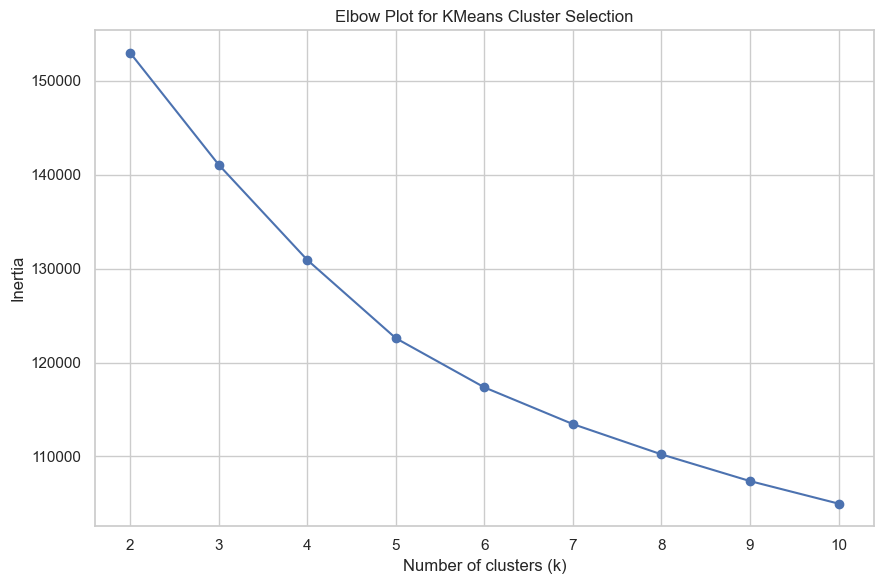

Estimated elbow k: 5


In [18]:
pca_fit = PCA(n_components=10, random_state=42)
X_pca_fit = pca_fit.fit_transform(X_scaled)
print('Explained variance ratio (10 components):', pca_fit.explained_variance_ratio_)
print('Cumulative explained variance (10 components):', round(pca_fit.explained_variation_ratio_.sum(), 4) if hasattr(pca_fit, 'explained_variation_ratio_') else round(pca_fit.explained_variance_ratio_.sum(), 4))

pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca_vis, columns=['PC1', 'PC2'])

k_values = list(range(2, 11))
inertias = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    model.fit(X_pca_fit)
    inertias.append(model.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker='o')
plt.xticks(k_values)
plt.title('Elbow Plot for KMeans Cluster Selection')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'elbow_plot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


def estimate_elbow(x_values, y_values):
    x_arr = np.array(x_values, dtype=float)
    y_arr = np.array(y_values, dtype=float)
    start = np.array([x_arr[0], y_arr[0]])
    end = np.array([x_arr[-1], y_arr[-1]])
    line = end - start
    line_norm = np.linalg.norm(line)
    if line_norm == 0:
        return int(x_arr[len(x_arr) // 2])
    distances_to_line = np.abs((line[1] * x_arr - line[0] * y_arr + end[0] * start[1] - end[1] * start[0]) / line_norm)
    elbow_index = int(np.argmax(distances_to_line))
    return int(x_arr[elbow_index])

optimal_k = estimate_elbow(k_values, inertias)
if optimal_k < 2:
    optimal_k = 2
print('Estimated elbow k:', optimal_k)

## KMeans clustering
KMeans is fitted on the 10-component PCA space using the elbow-selected `k`. Cluster counts are reported and the 2D PCA and t-SNE plots use the resulting labels.

Cluster counts:
0    1687
1    2638
2    1412
3    2493
4    1770
Name: count, dtype: int64


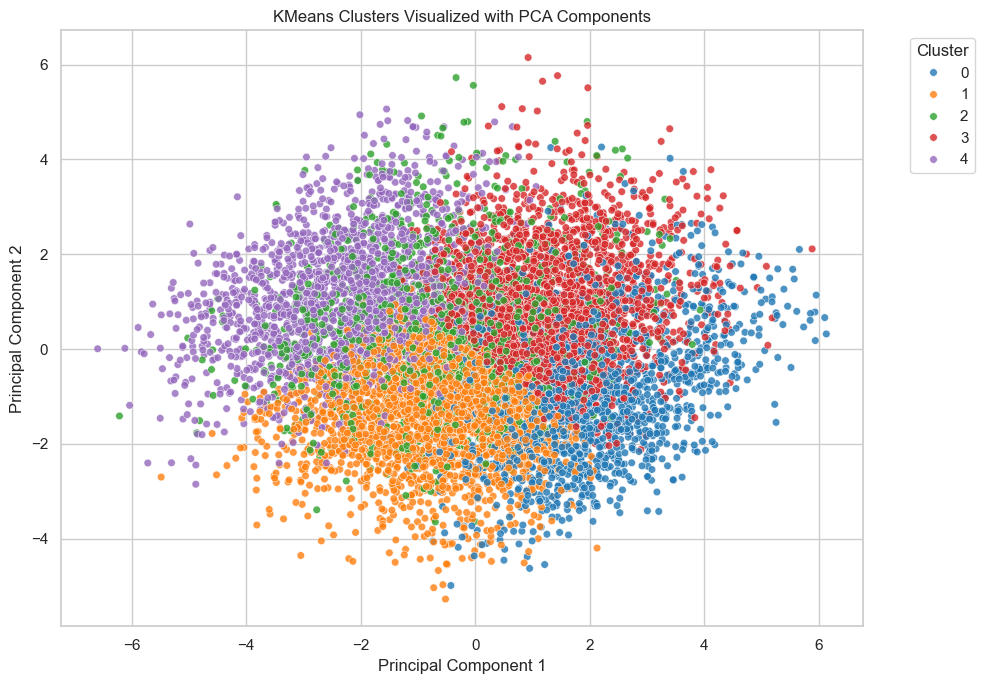

In [19]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca_fit)
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print('Cluster counts:')
print(cluster_counts)

pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=30, alpha=0.8)
plt.title('KMeans Clusters Visualized with PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## t-SNE visualization and silhouette score
t-SNE offers a second look at cluster separation. Silhouette score is computed after excluding noise points.

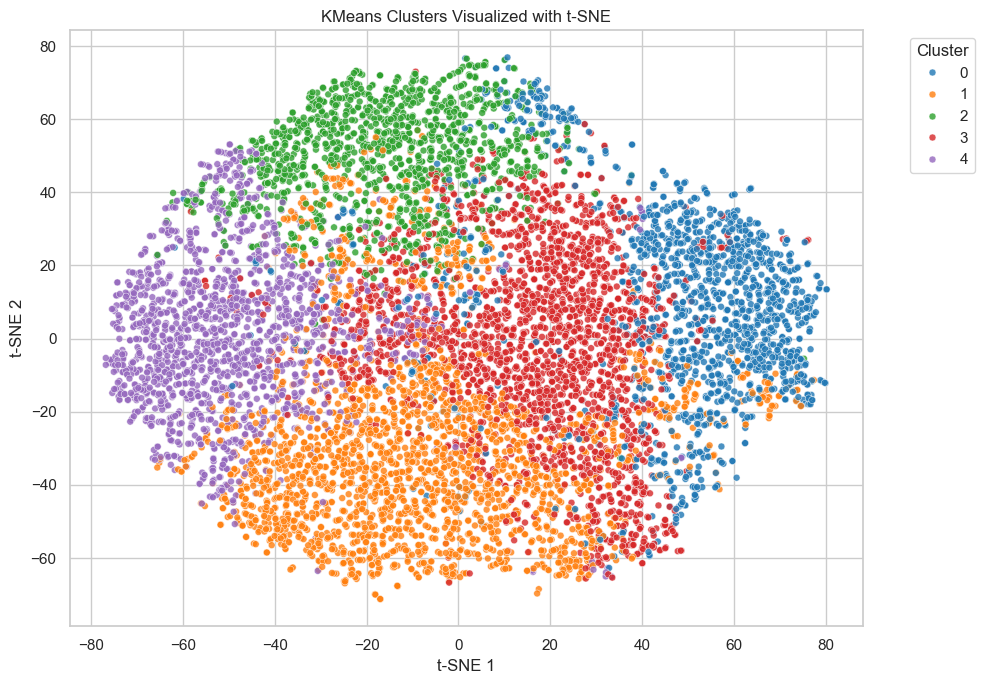

Silhouette Score: 0.111


In [20]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_pca_fit)
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10', s=25, alpha=0.8)
plt.title('KMeans Clusters Visualized with t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tsne_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

score = silhouette_score(X_pca_fit, cluster_labels)
print('Silhouette Score:', round(score, 4))

## Cluster profiling and export
Each cluster is summarized by mean feature values, then the cluster labels are merged back into the dataset and exported.

In [21]:
profile_df = source_df.copy()
profile_df['Cluster'] = cluster_labels
print('Cluster profile means:')
display(profile_df.groupby('Cluster').mean(numeric_only=True))

profile_df.to_csv(PROCESSED_DIR / 'clustered_data.csv', index=False)
print('Clustered data saved to', PROCESSED_DIR / 'clustered_data.csv')
print('Clustering complete. Summary rows:', profile_df.shape[0])

Cluster profile means:


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,4988.692946,37.592472,40490.086841,555.749555,0.209840,1.912863,15.344991,40414.274526,44.628334,1.254890,1.500889,1.423829,480.783640,0.281637,3.060462,0.973325,0.275598,0.061055,1.860107,0.096028,23.892709,14.578542,4263.700652,1531.161826,70922.168346,32687.217620,3353.818841,0.803284,5.100771,45374.360551,0.257038,0.258397,1570.434863,0.722174,0.001186,54.543094
1,5085.525019,44.862396,44395.271039,601.881729,0.223654,1.883624,22.514784,19245.206217,45.666414,1.250190,1.514026,1.392722,449.954132,0.288193,2.962092,0.986732,0.284202,0.048901,1.840788,0.094769,24.029189,14.592494,4103.000379,1524.340030,55421.863533,34065.535633,3685.470464,0.804119,4.958870,31004.622441,0.211360,0.208618,701.611284,0.369136,0.138741,52.108795
2,5001.474504,39.400142,52336.314802,573.428470,0.205382,1.943343,17.160057,22268.969370,54.067989,1.223088,1.491501,1.421388,441.510623,0.286679,3.033286,0.973796,0.274801,0.039660,1.830737,0.092776,23.963881,15.480170,4165.264164,1538.472380,214847.837110,25558.162181,4339.339375,0.802839,5.031161,182929.086048,0.235699,0.235243,770.117691,0.349188,0.389518,45.561331
3,4972.517048,32.795026,47053.348125,538.738468,0.235459,1.883273,10.699559,21003.090804,70.089049,1.283594,1.584838,1.381869,430.070999,0.293369,3.038107,1.005215,0.302151,0.065784,1.897312,0.123947,23.842760,14.896911,4243.611713,1483.184918,58873.322904,31690.276925,3905.669947,0.801155,4.963297,35410.614822,0.265053,0.267650,640.132864,0.337464,0.037706,55.230646
4,4918.018644,44.007910,109643.255579,589.561582,0.226554,1.895480,21.636158,22880.398446,52.766102,1.255367,1.485876,1.415254,427.236158,0.274581,2.936723,1.005085,0.267250,0.029944,1.796610,0.078531,23.949153,15.648023,4250.068362,1487.959322,74349.396045,30928.221822,9056.956221,0.801314,4.978531,49733.296469,0.227237,0.225019,795.502352,0.136329,0.809605,42.230508


Clustered data saved to D:\Financial-Risk-Classification-and-Behavioral-Pattern-Clustering\data\processed\clustered_data.csv
Clustering complete. Summary rows: 10000
